In [4]:
# ============================================================
# 설정 (여기만 수정)
# ============================================================

# 시뮬레이션 인덱스 (0 ~ 1999)
SIM_IDX = 1133

# 데이터 구간
TEST_START = 1704
TEST_END   = 2000

# 모델 하이퍼파라미터
LAG        = 1
HIDDEN     = [100]
ACTIVATION = "relu"

# 학습 하이퍼파라미터
LR         = 1e-2
MAX_ITER   = 1500
CHECK_EVERY = 100

# Lambda sweep 범위
LAM_MIN    = 0.05   # 최소 lambda
LAM_MAX    = 10    # 최대 lambda
LAM_NUM    = 10     # lambda 개수

# 디바이스
USE_DEVICE = "cuda:6"  # "cuda:6" / "mps" / "cpu"


In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from models.cmlp import cMLP, train_model_ista

# 디바이스 설정
def get_device(name):
    if name.startswith("cuda"):
        return torch.device(name) if torch.cuda.is_available() else torch.device("cpu")
    if name == "mps":
        return torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    return torch.device("cpu")

device = get_device(USE_DEVICE)
print(f"Device: {device}")

# 데이터 로드
h5_path = "simulated/260420_data/four_nodes/signal.h5"
with h5py.File(h5_path, "r") as f:
    X_np = f["signal"][()].astype(np.float32)  # (2000, 4, 2000)

X_np = X_np.transpose(0, 2, 1)  # (2000, 2000, 4)

X_single = X_np[SIM_IDX, TEST_START:TEST_END, :]  # (296, 4)
print(f"Sim index: {SIM_IDX}")
print(f"Data shape: {X_single.shape}  (timestep={TEST_END - TEST_START}, nodes={X_single.shape[1]})")


Device: cuda:6
Sim index: 1133
Data shape: (296, 4)  (timestep=296, nodes=4)


In [ ]:
import time

lambdas = np.logspace(np.log10(LAM_MIN), np.log10(LAM_MAX), LAM_NUM)
print(f"Lambdas: {np.round(lambdas, 6)}")

gc_results = []  # (lambda, 3, 3) binary

start = time.time()
for lam in lambdas:
    X_t = torch.tensor(X_single, dtype=torch.float32).unsqueeze(0).to(device)

    model = cMLP(
        num_series=X_t.shape[-1],
        lag=LAG,
        hidden=HIDDEN,
        activation=ACTIVATION,
    ).to(device)

    train_model_ista(
        model, X_t,
        lam=float(lam),
        lr=LR,
        max_iter=MAX_ITER,
        check_every=CHECK_EVERY,
        verbose=0,
    )

    gc = model.GC().detach().cpu().numpy()
    gc_results.append(gc)
    print(f"lam={lam:.4g}  GC sum={gc.sum()}")

print(f"Total time: {time.time()-start:.1f}s")


Lambdas: [ 0.05      0.090082  0.162297  0.292402  0.526805  0.949118  1.709976
  3.080775  5.550473 10.      ]
lam=0.05  GC sum=16
lam=0.09008  GC sum=16
lam=0.1623  GC sum=16
lam=0.2924  GC sum=6
lam=0.5268  GC sum=6
lam=0.9491  GC sum=3
lam=1.71  GC sum=0
lam=3.081  GC sum=0
lam=5.55  GC sum=0
lam=10  GC sum=0
Total time: 91.5s


: 

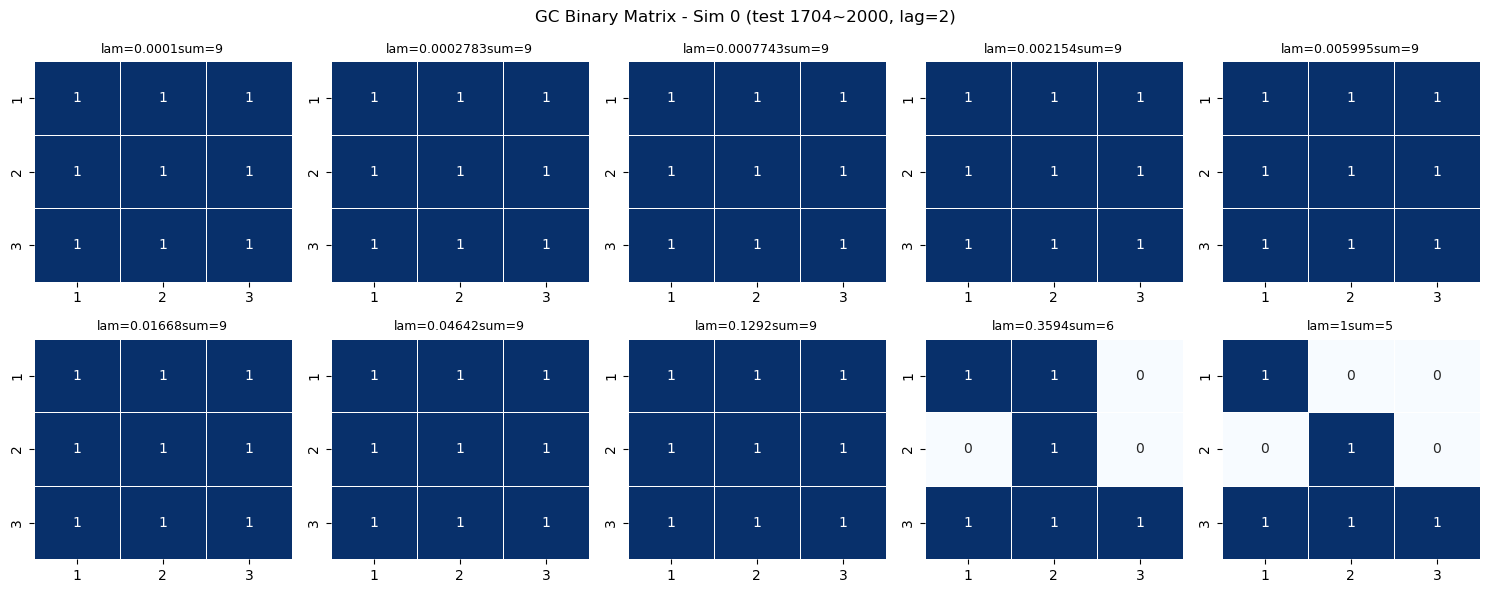

In [6]:
# Lambda별 GC binary matrix 시각화
n = len(lambdas)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = axes.flatten()

for i, (lam, gc) in enumerate(zip(lambdas, gc_results)):
    sns.heatmap(
        gc,
        ax=axes[i],
        annot=True,
        fmt=".0f",
        cmap="Blues",
        vmin=0, vmax=1,
        linewidths=0.5,
        cbar=False,
        xticklabels=[1,2,3,4],
        yticklabels=[1,2,3,4],
    )
    axes[i].set_title(f"lam={lam:.4g}sum={gc.sum():.0f}", fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"GC Binary Matrix - Sim {SIM_IDX} (test {TEST_START}~{TEST_END}, lag={LAG})", fontsize=12)
plt.tight_layout()
plt.show()